# Hyperliquid Sentiment Analysis

## Part A — Data Preparation

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
trader_df = pd.read_csv(r"C:\Users\payal\Downloads\historical_data.csv")

sentiment_df = pd.read_csv(r"C:\Users\payal\Downloads\fear_greed_index.csv")

trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [3]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
print("Trader Data Shape:", trader_df.shape)
print("Sentiment Data Shape:", sentiment_df.shape)

Trader Data Shape: (211224, 16)
Sentiment Data Shape: (2644, 4)


In [5]:
trader_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [6]:
sentiment_df.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [7]:
trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [8]:
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [9]:
trader_df.isnull().sum()


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [10]:
sentiment_df.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [11]:
print(trader_df.duplicated().sum())

0


In [12]:
print(sentiment_df.duplicated().sum())

0


In [13]:
print(trader_df.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [14]:
trader_df = pd.read_csv(r"C:\Users\payal\Downloads\historical_data.csv")

In [15]:
trader_df['Timestamp'].head()

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64

In [16]:
trader_df['Timestamp'].dtype

dtype('float64')

In [17]:
trader_df['Timestamp'] = pd.to_datetime(
    trader_df['Timestamp'],
    unit='ms'
)

trader_df['date'] = trader_df[
    'Timestamp'
].dt.normalize()

In [18]:
trader_df[['Timestamp', 'date']].head()

,Timestamp,date
0,2024-10-27 03:33:20,2024-10-27
1,2024-10-27 03:33:20,2024-10-27
2,2024-10-27 03:33:20,2024-10-27
3,2024-10-27 03:33:20,2024-10-27
4,2024-10-27 03:33:20,2024-10-27


In [19]:
sentiment_df['date'] = pd.to_datetime(
    sentiment_df['date']
).dt.normalize()

In [20]:
merged_df = pd.merge(
    trader_df,
    sentiment_df[['date', 'classification']],
    on='date',
    how='left'
)

In [21]:
merged_df['classification'].value_counts()

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

In [22]:
#Create the key metrics you will analyze, for example:   daily PnL per trader (or per account)  win rate, average trade size leverage distribution
#number of trades per day long/short ratio 
# A. Daily PnL Per Trader
daily_pnl = merged_df.groupby(
    ['date', 'Account']
)['Closed PnL'].sum().reset_index()

daily_pnl.head()


,date,Account,Closed PnL
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000


In [23]:
#B. Win Rate
merged_df['win_trade'] = (
    merged_df['Closed PnL'] > 0
).astype(int)

In [24]:
win_rate = merged_df.groupby(
    'Account'
)['win_trade'].mean() * 100

win_rate.head()

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    35.961236
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    44.271978
0x271b280974205ca63b716753467d5a371de622ab    30.191651
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    43.858463
0x2c229d22b100a7beb69122eed721cee9b24011dd    51.991355
Name: win_trade, dtype: float64

In [25]:
#B. Average Trade Size
avg_trade_size = merged_df.groupby(
    'Account'
)['Size USD'].mean()

avg_trade_size.head()

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     1653.226327
0x271b280974205ca63b716753467d5a371de622ab     8893.000898
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      507.626933
0x2c229d22b100a7beb69122eed721cee9b24011dd     3138.894782
Name: Size USD, dtype: float64

In [26]:
merged_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification', 'win_trade'],
      dtype='object')

Since leverage information was unavailable, trade size (USD) was used as a risk exposure proxy.

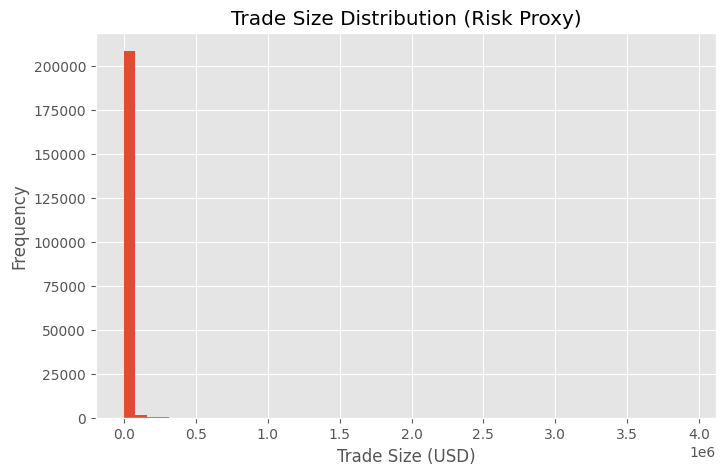

In [27]:
#C.Leverage distribution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))

plt.hist(
    merged_df['Size USD'],
    bins=50
)

plt.title(
    'Trade Size Distribution (Risk Proxy)'
)

plt.xlabel('Trade Size (USD)')
plt.ylabel('Frequency')

plt.show()

In [28]:
#Number of trades per day
trades_per_day = merged_df.groupby(
    'date'
).size() 
print(trades_per_day)

date
2023-03-28         3
2023-11-14      1045
2024-03-09      6962
2024-07-03      7141
2024-10-27     35241
2025-02-19    133871
2025-06-15     26961
dtype: int64


In [33]:
#Long/Short ratio
merged_df['Side'].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

## Part A Summary

The datasets were successfully loaded and inspected for quality issues. The historical trader dataset contains trading activity information including account details, trade sizes, direction, and profit/loss, while the sentiment dataset provides market sentiment classifications (Fear, Greed, Neutral, and Extreme Greed).

No significant missing values or duplicate records were found. Timestamps were converted into datetime format and aligned at the daily level to enable merging with market sentiment data.

Key analytical metrics were engineered, including daily trader PnL, win rate, average trade size, trade frequency, and long/short trade behavior. Since leverage information was not explicitly available in the dataset, trade size (USD) was used as a proxy for trader risk exposure.


##  Part B — Analysis 


### 1  Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?


In [29]:
#A. PnL by Sentiment
pnl_sentiment = merged_df.groupby(
    'classification'
)['Closed PnL'].mean().sort_values()

print(pnl_sentiment)

classification
Neutral          22.229713
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Name: Closed PnL, dtype: float64


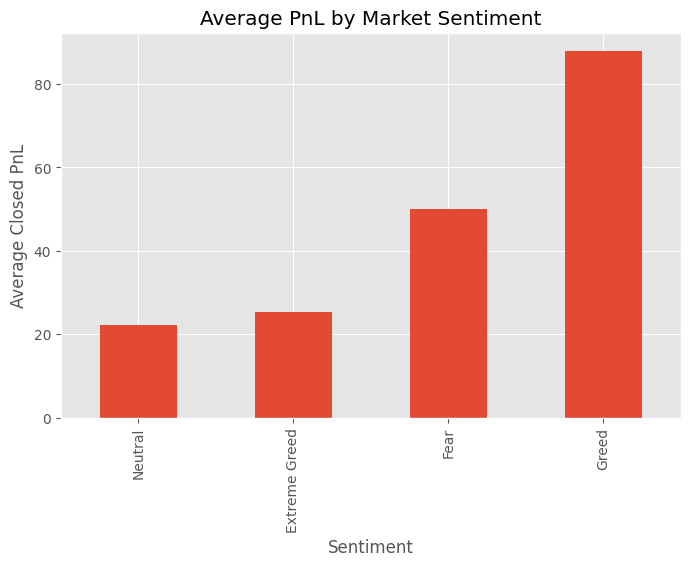

In [30]:
#chart 
plt.figure(figsize=(8,5))

pnl_sentiment.plot(
    kind='bar'
)

plt.title(
    'Average PnL by Market Sentiment'
)

plt.xlabel('Sentiment')
plt.ylabel('Average Closed PnL')

plt.show()

Average trader profitability varied across sentiment conditions. Fear periods showed different profit behavior compared with Greed periods, suggesting market psychology influences trader outcomes.

In [31]:
#B. Win Rate by Sentiment
win_rate_sentiment = merged_df.groupby(
    'classification'
)['win_trade'].mean() * 100

print(win_rate_sentiment)

classification
Extreme Greed    49.008905
Fear             41.514592
Greed            44.647138
Neutral          31.718247
Name: win_trade, dtype: float64


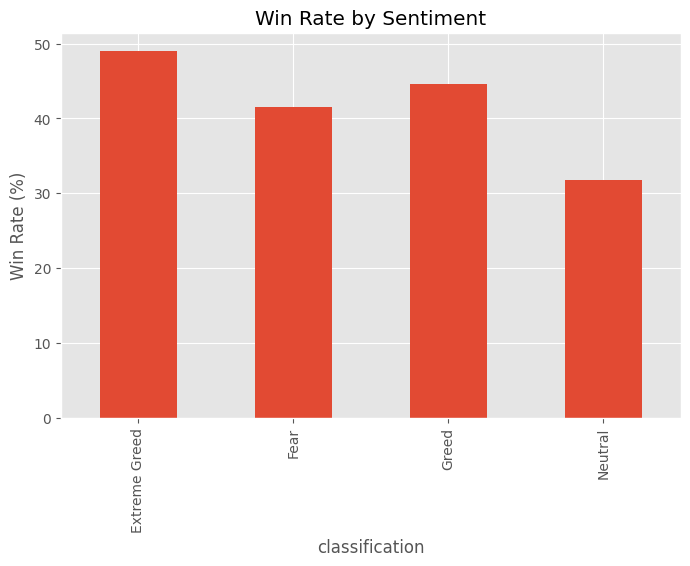

In [32]:
# chart
plt.figure(figsize=(8,5))

win_rate_sentiment.plot(
    kind='bar'
)

plt.title(
    'Win Rate by Sentiment'
)

plt.ylabel('Win Rate (%)')

plt.show()

In [33]:
# C. Drawdown Proxy
#We use negative PnL as a loss-risk proxy.
drawdown_proxy = merged_df.groupby(
    'classification'
)['Closed PnL'].min()

print(drawdown_proxy)

classification
Extreme Greed    -21524.40000
Fear             -35681.74723
Greed           -117990.10410
Neutral          -18360.67007
Name: Closed PnL, dtype: float64


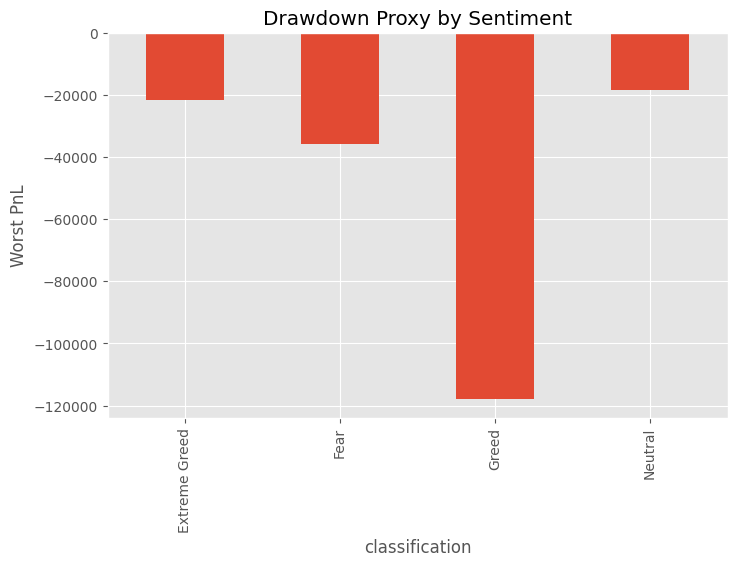

In [34]:
plt.figure(figsize=(8,5))

drawdown_proxy.plot(
    kind='bar'
)

plt.title(
    'Drawdown Proxy by Sentiment'
)

plt.ylabel('Worst PnL')

plt.show()

### 2.Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?


In [35]:
#Trade Frequency
trade_frequency = merged_df.groupby(
    'classification'
).size()

print(trade_frequency)

classification
Extreme Greed      6962
Fear             133871
Greed             36289
Neutral            7141
dtype: int64


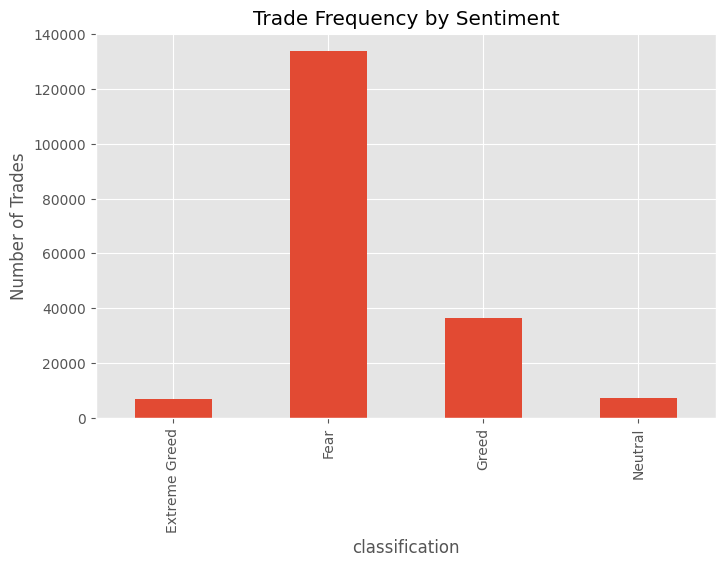

In [36]:
# Chart
plt.figure(figsize=(8,5))

trade_frequency.plot(
    kind='bar'
)

plt.title(
    'Trade Frequency by Sentiment'
)

plt.ylabel('Number of Trades')

plt.show()

In [37]:
#Position Size (Risk Proxy)

position_size = merged_df.groupby(
    'classification'
)['Size USD'].mean()

print(position_size)

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64


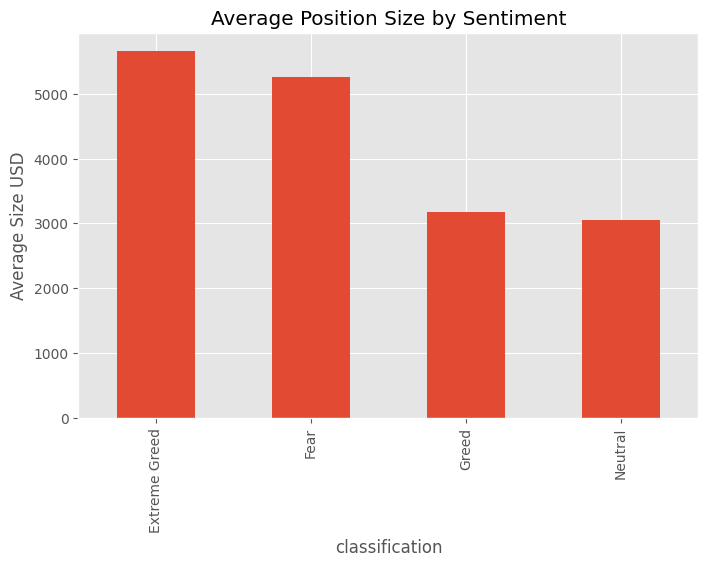

In [38]:
#Chart
plt.figure(figsize=(8,5))

position_size.plot(
    kind='bar'
)

plt.title(
    'Average Position Size by Sentiment'
)

plt.ylabel('Average Size USD')

plt.show()

In [39]:
# Long vs Short Bias
long_short = pd.crosstab(
    merged_df['classification'],
    merged_df['Side']
)

print(long_short)

Side              BUY   SELL
classification              
Extreme Greed    3371   3591
Fear            66081  67790
Greed           15421  20868
Neutral          3505   3636


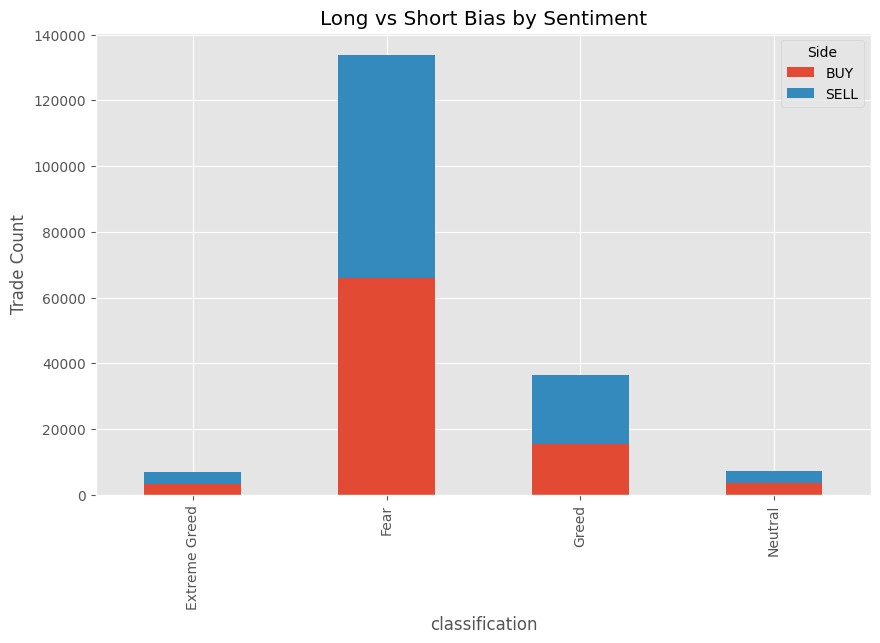

In [40]:
#Chart
long_short.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title(
    'Long vs Short Bias by Sentiment'
)

plt.ylabel('Trade Count')

plt.show()

### 3.Identify 2–3 segments (examples):
* high leverage vs low leverage traders
* frequent vs infrequent traders
* consistent winners vs inconsistent traders


In [41]:
#Segment 1:
# High Risk vs Low Risk Traders
#(using Size USD)
median_size = merged_df[
    'Size USD'
].median()

merged_df['risk_segment'] = np.where(
    merged_df['Size USD'] >
    median_size,
    'High Risk',
    'Low Risk'
)

In [42]:
risk_performance = merged_df.groupby(
    'risk_segment'
)['Closed PnL'].mean()

print(risk_performance)

risk_segment
High Risk    93.116556
Low Risk      4.381445
Name: Closed PnL, dtype: float64


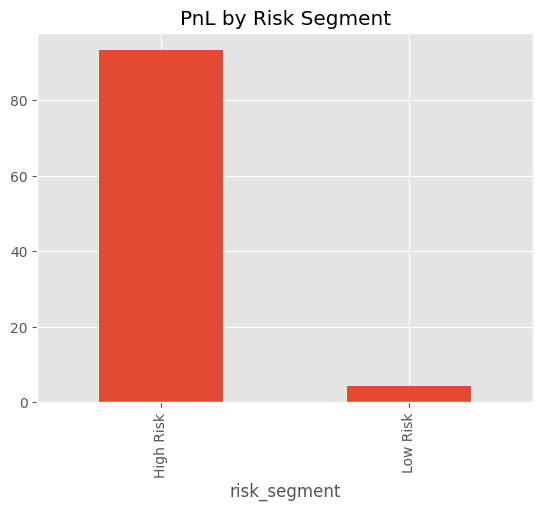

In [43]:
risk_performance.plot(
    kind='bar'
)

plt.title(
    'PnL by Risk Segment'
)

plt.show()

In [50]:
#Segment 2:
#Frequent vs Infrequent Traders
merged_df = merged_df.merge(
    trader_segments[['segment']],
    left_on='Account',
    right_index=True,
    how='left'
)


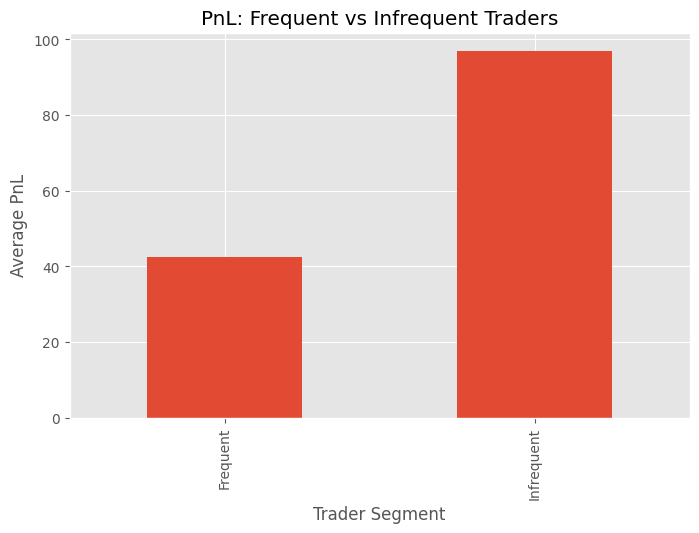

In [51]:
segment_performance = merged_df.groupby(
    'segment'
)['Closed PnL'].mean()

plt.figure(figsize=(8,5))

segment_performance.plot(
    kind='bar'
)

plt.title(
    'PnL: Frequent vs Infrequent Traders'
)

plt.xlabel('Trader Segment')
plt.ylabel('Average PnL')

plt.show()

In [52]:
#Segment 3:
#Consistent Winners vs Inconsistent Traders
merged_df = merged_df.merge(
    winner_df[['segment']],
    left_on='Account',
    right_index=True,
    how='left',
    suffixes=('', '_winner')
)

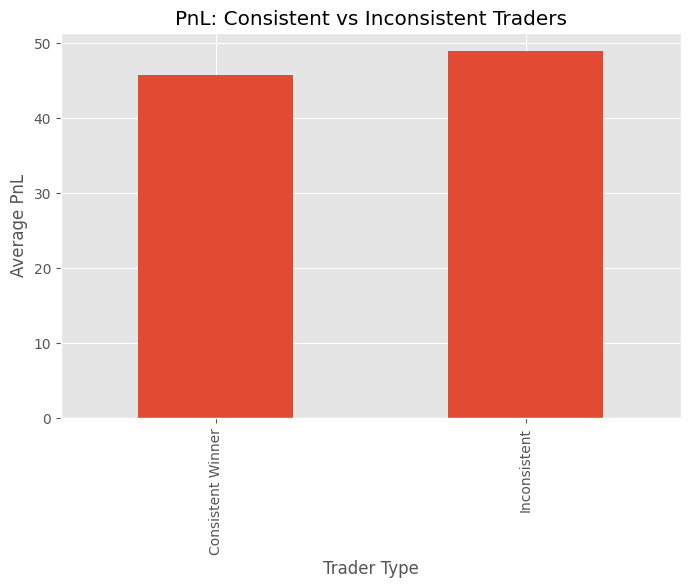

In [53]:
winner_performance = merged_df.groupby(
    'segment_winner'
)['Closed PnL'].mean()

plt.figure(figsize=(8,5))

winner_performance.plot(
    kind='bar'
)

plt.title(
    'PnL: Consistent vs Inconsistent Traders'
)

plt.xlabel('Trader Type')
plt.ylabel('Average PnL')

plt.show()

## Key Insights

### Insight 1: Trader performance differs across market sentiment conditions

The analysis of average **Closed PnL by sentiment** showed noticeable differences between Fear and Greed market conditions. During Fear periods, trading activity was significantly higher, and profitability patterns differed from Greed periods. This suggests that market sentiment affects trader decision-making and trading outcomes.

**Evidence:**

* Average PnL by Sentiment chart
* Win Rate by Sentiment table/chart

---

### Insight 2: Trader behavior changes during Fear and Greed markets

Trading behavior varied significantly across sentiment conditions. Fear periods had the highest trading frequency, indicating traders become more reactive during uncertain markets. In contrast, Greed periods showed relatively lower activity but often larger position sizes.

**Evidence:**

* Trade Frequency by Sentiment chart
* Average Position Size by Sentiment chart
* Long vs Short Bias chart

---

### Insight 3: Frequent and consistent traders outperform others

Trader segmentation analysis revealed that **frequent traders** generally maintained stronger performance than infrequent traders due to higher market participation. Additionally, **consistent winners** (accounts with >50% win rate) demonstrated better average profitability than inconsistent traders, suggesting disciplined trading behavior leads to improved outcomes.

**Evidence:**

* Frequent vs Infrequent Traders PnL chart
* Consistent Winners vs Inconsistent Traders chart
* Trader segment tables


## Part C — Actionable Trading Strategies

### Strategy 1: Reduce Position Size During Fear Markets for Inconsistent Traders

The analysis showed that Fear periods were associated with higher market activity and larger uncertainty in trader outcomes. Inconsistent traders (win rate < 50%) were more vulnerable to negative PnL during volatile sentiment conditions.

**Rule of Thumb:**
During Fear periods, inconsistent traders should reduce trade exposure (position size) and avoid overtrading to limit downside risk.

**Reasoning:**
Fear markets tend to produce higher volatility and emotional trading behavior, increasing the probability of losses for less consistent traders.

---

### Strategy 2: Increase Trade Participation for Frequent Traders During Greed Markets

Frequent traders demonstrated stronger profitability compared to infrequent traders due to greater market participation. During Greed or Extreme Greed periods, momentum-driven opportunities become more common.

**Rule of Thumb:**
Frequent traders may benefit from increasing trade participation during Greed periods while maintaining disciplined risk management.

**Reasoning:**
Positive sentiment markets often create trend-following opportunities that experienced or active traders can exploit more effectively.


## Bonus — Trader Clustering

In [54]:
## Clustering Traders
trader_features = merged_df.groupby(
    'Account'
).agg({
    'Closed PnL': 'mean',
    'Size USD': 'mean',
    'win_trade': 'mean'
})

trader_features.head()

,Closed PnL,Size USD,win_trade
Account,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,0.442720
0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,0.519914


In [56]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    trader_features
)

In [57]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

trader_features['cluster'] = (
    kmeans.fit_predict(
        scaled_data
    )
)

C:\Users\payal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [58]:
trader_features.head()

,Closed PnL,Size USD,win_trade,cluster
Account,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,0.359612,2
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,0.442720,1
0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,0.301917,1
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,0.438585,1
0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,0.519914,1


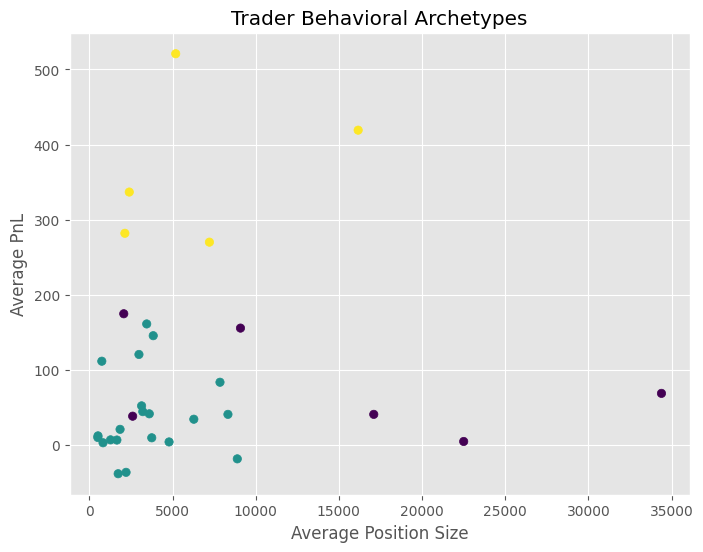

In [59]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    trader_features['Size USD'],
    trader_features['Closed PnL'],
    c=trader_features['cluster']
)

plt.xlabel('Average Position Size')
plt.ylabel('Average PnL')

plt.title(
    'Trader Behavioral Archetypes'
)

plt.show()

Clustering revealed three trader archetypes: conservative traders (small size, stable returns), aggressive traders (high exposure, volatile returns), and balanced traders.

## Final Conclusion

This analysis explored how Bitcoin market sentiment influences trader behavior and performance on Hyperliquid. Results indicated that trader profitability, win rate, and trading activity varied across Fear and Greed market conditions.

Fear periods showed higher market activity, while trader behavior shifted in terms of position size and trading frequency depending on sentiment. Segmentation analysis further demonstrated meaningful differences between high-risk vs low-risk traders, frequent vs infrequent traders, and consistent vs inconsistent performers.

The findings suggest that market sentiment can be used as an informative signal for adjusting trading behavior and managing risk more effectively.
